In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
%matplotlib inline

In [5]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

In [6]:
from sklearn.ensemble import RandomForestRegressor

In [7]:
from sklearn.model_selection import train_test_split

In [13]:
import numpy as np

In [14]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/4. Feature Engineering/Ft Engineering(One-Hot).csv")

In [15]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,False,False,...,False,False,2010,0.652664,1.000000,0.464789,1.000000,0,High,2
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,False,False,...,False,False,2010,0.651018,1.033601,0.295353,1.014898,0,High,2
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,False,False,...,False,False,2000,1.084842,0.701708,0.277804,0.718266,0,High,2
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,False,False,...,False,False,2010,1.189320,0.693285,0.036090,0.583115,0,Medium,1
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,False,False,...,False,False,2010,0.853220,0.827640,0.259374,1.053799,1,High,2


In [16]:
df.dtypes # check data types

Game Title               object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
                         ...   
JP Share                float64
Other Share             float64
Is Recent                 int64
Game Quality             object
Game Quality Encoded      int64
Length: 133, dtype: object

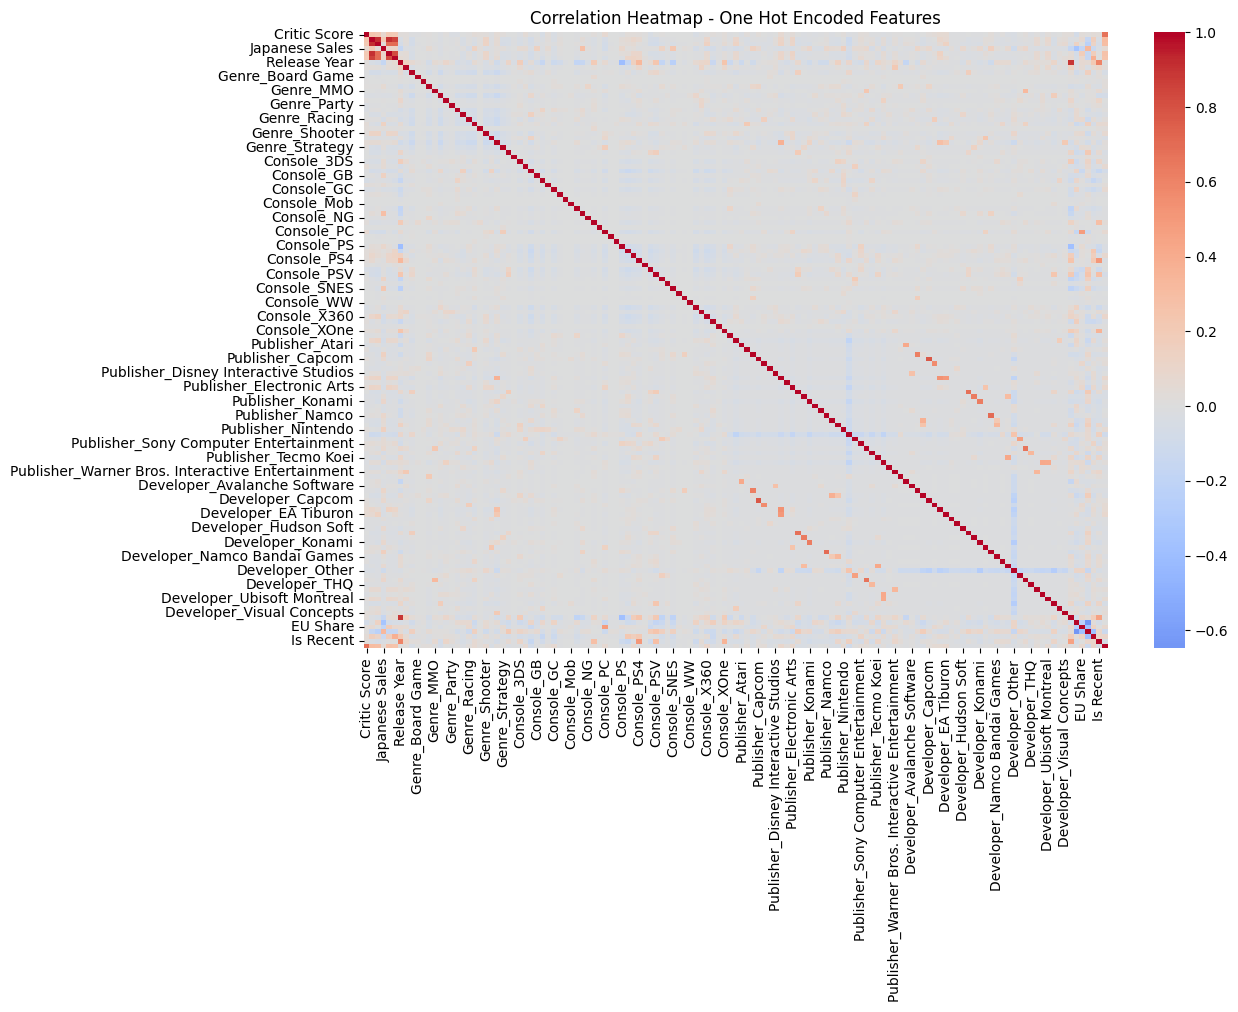

In [17]:
# Correlation Heatmap (EDA step)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - One Hot Encoded Features")
plt.show()

In [18]:
# Variance Threshold

X = df.drop(columns=["Sales"]).select_dtypes(include="number").copy()
y = df["Sales"].astype(float)

# make it finite + numeric
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

vt = VarianceThreshold(threshold=0.001)
X_vt = X.loc[:, vt.fit(X).get_support()]

print("Original features:", X.shape[1])
print("After VarianceThreshold:", X_vt.shape[1])

Original features: 13
After VarianceThreshold: 13


Top MI features:
 Other Share             1.915631
NA Share                1.443495
EU Share                1.373754
North American Sales    1.145003
JP Share                0.785137
Other Sales             0.749568
EU Sales                0.702424
Japanese Sales          0.582946
Critic Score            0.082248
Release Year            0.045919
Game Quality Encoded    0.044292
Decade                  0.037441
Is Recent               0.018121
dtype: float64


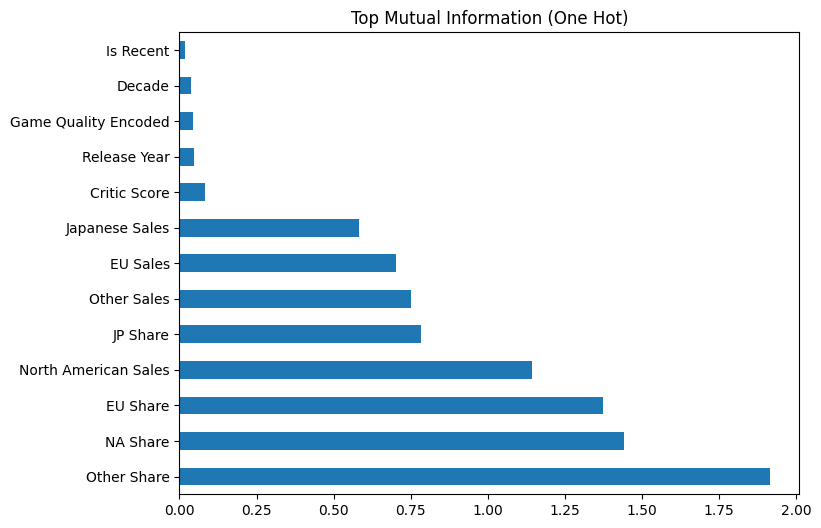

In [19]:
# Mutual Information

mi = mutual_info_regression(X_vt.fillna(0), y)
mi_scores = pd.Series(mi, index=X_vt.columns).sort_values(ascending=False)

print("Top MI features:\n", mi_scores.head(15))

mi_scores.head(15).plot(kind="barh", figsize=(8,6), title="Top Mutual Information (One Hot)")
plt.show()

In [ ]:
# Random Forest Importance

X_train, X_test, y_train, y_test = train_test_split(X_vt.fillna(0), y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X_vt.columns).sort_values(ascending=False)

print("Top RF features:\n", rf_importances.head(15))

rf_importances.head(15).plot(kind="barh", figsize=(8,6), title="Random Forest Importance (One Hot)")
plt.show()

In [20]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/5. Feature Selection/Feature Selection(1-hot).csv", index=False)